# ATSSB_ARIMA016_Residuals
## Generates residual p-value plots for ARIMA(0,1,6) model

In [1]:
# Install required packages if needed
# !pip install pythontsa
# !pip install --upgrade matplotlib

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PythonTsa.LjungBoxtest import plot_LB_pvalue
from statsmodels.tsa.arima.model import ARIMA
from PythonTsa.datadir import getdtapath
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set working directory
path = "/Users/ruting/Documents/macbook/PcBack/30.ATSSB_Code/Code/ATSSB_ARIMA016_Residuals"
os.chdir(path)

In [3]:
# Load US bill data
dtapath = getdtapath()
rat = pd.read_csv(dtapath + 'USbill.csv', header=None)
y = rat[:456]
y.rename(columns={0: 'time', 1: 'bill'}, inplace=True)
dates = pd.date_range('1950-1', periods=len(y), freq='M')
y.index = dates
y = y['bill']
ly = np.log(y)

In [4]:
# Fit ARIMA(0,1,6) model
arima016 = ARIMA(ly, order=(0, 1, 6), trend='n').fit(method='innovations_mle')

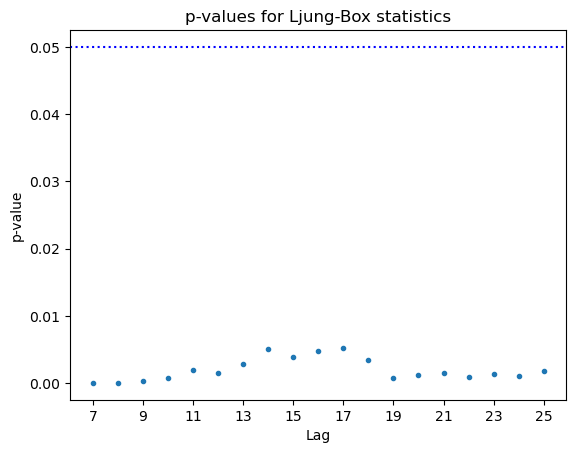

In [5]:
# Plot Ljung-Box p-value for residuals
plot_LB_pvalue(arima016.resid, noestimatedcoef=6, nolags=25)

# Save figures
plt.savefig('arima016ResidPvProb44.png', dpi=1200,
            bbox_inches='tight', transparent=True)
plt.savefig('arima016ResidPvProb44.eps', dpi=1200,
            bbox_inches='tight', transparent=True)
plt.show()
plt.close('all')

In [6]:
# Display model summary
print(arima016.summary())

                               SARIMAX Results                                
Dep. Variable:                   bill   No. Observations:                  456
Model:                 ARIMA(0, 1, 6)   Log Likelihood                 517.167
Date:                Sat, 11 Apr 2026   AIC                          -1020.333
Time:                        14:23:12   BIC                           -991.491
Sample:                    01-31-1950   HQIC                         -1008.971
                         - 12-31-1987                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4164      0.036     11.498      0.000       0.345       0.487
ma.L2          0.0152      0.046      0.327      0.744      -0.076       0.106
ma.L3          0.0412      0.043      0.968      0.3